In [8]:
import torch
import torch.nn as nn
from torchvision import datasets
from torch.utils.data import DataLoader, TensorDataset





In [9]:
# 
#                                                   Repro + device
# 

def set_seed(seed: int = 42):
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)


def get_device():
    return torch.device("cuda" if torch.cuda.is_available() else "cpu")


In [10]:

# 
#                                                   Donnee
# 


def load_mnist(batch_size=100, normalize=True):
    train_set = datasets.MNIST(root="data/", train=True, download=True)
    test_set  = datasets.MNIST(root="data/", train=False, download=True)

    X_train = train_set.data.view(train_set.data.size(0), -1).float()
    y_train = train_set.targets.long()

    X_test  = test_set.data.view(test_set.data.size(0), -1).float()
    y_test  = test_set.targets.long()

    if normalize:
        mu, std = X_train.mean(), X_train.std()
        X_train = (X_train - mu) / std
        X_test  = (X_test - mu) / std

    train_loader = DataLoader(TensorDataset(X_train, y_train), batch_size=batch_size, shuffle=True)
    test_loader  = DataLoader(TensorDataset(X_test, y_test), batch_size=batch_size, shuffle=False)

    return train_loader, test_loader

In [11]:

# 
#                                                               Modeles
# 



def get_linear_model():
    return nn.Sequential(nn.Linear(784, 10, bias=False))


def get_mlp(layers=(100,), in_dim=784, out_dim=10):
    net = []
    prev = in_dim
    for h in layers:
        net += [nn.Linear(prev, h), nn.ReLU()]
        prev = h
    net += [nn.Linear(prev, out_dim)]
    return nn.Sequential(*net)


In [12]:
# 
#                                               Entreinement (avec une L2)
# 




def train_model(model, train_loader, test_loader, device, epochs=50, lr=0.1, lambda_l2=0.0):
    model = model.to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.SGD(model.parameters(), lr=lr)

    history = {
        "train_loss": [],
        "test_loss": [],
        "test_acc": []
    }

    for e in range(epochs):
        # ---- TRAIN ----
        model.train()
        running = 0.0

        for X, y in train_loader:
            X, y = X.to(device), y.to(device)

            optimizer.zero_grad()
            logits = model(X)
            loss = criterion(logits, y)

            if lambda_l2 > 0:
                l2 = sum((p**2).sum() for p in model.parameters())
                loss = loss + lambda_l2 * l2

            loss.backward()
            optimizer.step()
            running += loss.item() * X.size(0)

        train_loss = running / len(train_loader.dataset)

        # ---- TEST ----
        model.eval()
        test_running = 0.0
        correct, total = 0, 0

        with torch.no_grad():
            for X, y in test_loader:
                X, y = X.to(device), y.to(device)
                logits = model(X)
                loss = criterion(logits, y)

                test_running += loss.item() * X.size(0)
                pred = logits.argmax(dim=1)
                correct += (pred == y).sum().item()
                total += y.numel()

        test_loss = test_running / len(test_loader.dataset)
        test_acc = correct / total

        history["train_loss"].append(train_loss)
        history["test_loss"].append(test_loss)
        history["test_acc"].append(test_acc)

        print(
            f"Epoch {e+1:03d} | "
            f"train_loss={train_loss:.4f} | "
            f"test_loss={test_loss:.4f} | "
            f"test_acc={100*test_acc:.2f}%"
        )

    return model, history


# 1) Expérience A:  Comparaison entre Linear et Shallow vs Deep 

On lances 3 entraînements, même config (epochs, lr), et on compare test_acc

In [13]:
import matplotlib.pyplot as plt

train_loader, test_loader = load_mnist(batch_size=100)
set_seed(42)
device = get_device()

models = {
    "Linear": get_linear_model(),
    "Shallow(100)": get_mlp((100,)),
    "Shallow(500)": get_mlp((500,)),
    "Deep(100,100)": get_mlp((100,100)),
    "Deep(500,500)": get_mlp((500,500)),
}

histories = {}

for name, model in models.items():
    print("\n====", name, "====")
    set_seed(42)
    _, hist = train_model(
        model,
        train_loader,
        test_loader,
        device,
        epochs=30,
        lr=0.1,
        lambda_l2=0.0
    )
    histories[name] = hist



==== Linear ====
Epoch 001 | train_loss=0.3664 | test_loss=0.2986 | test_acc=91.23%
Epoch 002 | train_loss=0.3044 | test_loss=0.2912 | test_acc=91.87%
Epoch 003 | train_loss=0.2928 | test_loss=0.2828 | test_acc=92.10%
Epoch 004 | train_loss=0.2862 | test_loss=0.2859 | test_acc=91.86%
Epoch 005 | train_loss=0.2809 | test_loss=0.2822 | test_acc=91.99%
Epoch 006 | train_loss=0.2779 | test_loss=0.2933 | test_acc=91.91%
Epoch 007 | train_loss=0.2749 | test_loss=0.2922 | test_acc=92.02%
Epoch 008 | train_loss=0.2733 | test_loss=0.2866 | test_acc=91.82%
Epoch 009 | train_loss=0.2707 | test_loss=0.2851 | test_acc=92.25%
Epoch 010 | train_loss=0.2700 | test_loss=0.2938 | test_acc=91.99%
Epoch 011 | train_loss=0.2674 | test_loss=0.2983 | test_acc=91.55%
Epoch 012 | train_loss=0.2670 | test_loss=0.2860 | test_acc=92.27%
Epoch 013 | train_loss=0.2660 | test_loss=0.2858 | test_acc=92.00%
Epoch 014 | train_loss=0.2648 | test_loss=0.2863 | test_acc=92.03%
Epoch 015 | train_loss=0.2636 | test_loss=0.

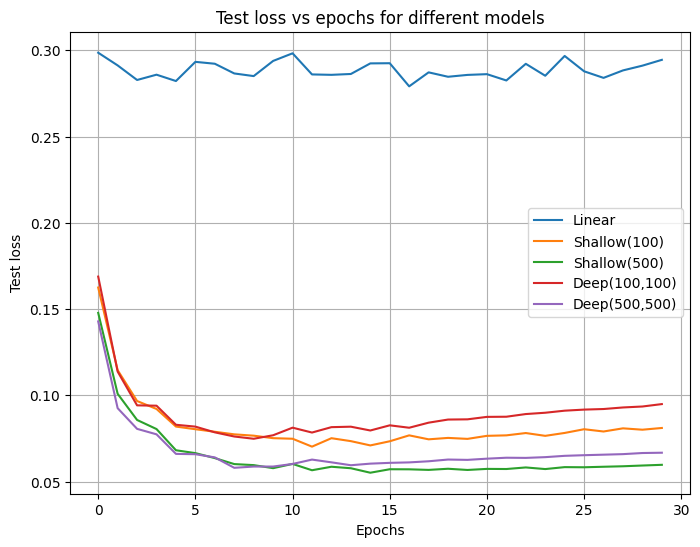

In [14]:
plt.figure(figsize=(8,6))

for name, hist in histories.items():
    plt.plot(hist["test_loss"], label=name)

plt.xlabel("Epochs")
plt.ylabel("Test loss")
plt.title("Test loss vs epochs for different models")
plt.legend()
plt.grid(True)
plt.show()


# 2) Expérience B: Recherche du bon nombre de neurones (shalow)

On fait une boucle sur les tailles de couche cachée et on stockes la meilleure performance.

In [15]:
widths = [100,200,300,400,500,600,700,800,900,1000]
rows = []

for w in widths:
    print("\n--- width =", w, "---")
    set_seed(42)
    model = get_mlp(layers=(w,))
    trained, hist = train_model(model, train_loader, test_loader, device, epochs=40, lr=0.1, lambda_l2=0.0)
    rows.append({
        "width": w,
        "final_acc": hist["test_acc"][-1],
        "best_acc": max(hist["test_acc"]),
        "final_train_loss": hist["train_loss"][-1],
    })

rows[:3]



--- width = 100 ---
Epoch 001 | train_loss=0.3096 | test_loss=0.1669 | test_acc=95.13%
Epoch 002 | train_loss=0.1435 | test_loss=0.1162 | test_acc=96.57%
Epoch 003 | train_loss=0.1012 | test_loss=0.0958 | test_acc=97.19%
Epoch 004 | train_loss=0.0789 | test_loss=0.0920 | test_acc=97.12%
Epoch 005 | train_loss=0.0645 | test_loss=0.0836 | test_acc=97.53%
Epoch 006 | train_loss=0.0544 | test_loss=0.0740 | test_acc=97.73%
Epoch 007 | train_loss=0.0461 | test_loss=0.0720 | test_acc=97.85%
Epoch 008 | train_loss=0.0395 | test_loss=0.0686 | test_acc=97.91%
Epoch 009 | train_loss=0.0343 | test_loss=0.0730 | test_acc=97.87%
Epoch 010 | train_loss=0.0298 | test_loss=0.0722 | test_acc=97.78%
Epoch 011 | train_loss=0.0259 | test_loss=0.0704 | test_acc=97.90%
Epoch 012 | train_loss=0.0225 | test_loss=0.0714 | test_acc=97.78%
Epoch 013 | train_loss=0.0196 | test_loss=0.0693 | test_acc=97.91%
Epoch 014 | train_loss=0.0167 | test_loss=0.0730 | test_acc=97.73%
Epoch 015 | train_loss=0.0151 | test_loss

[{'width': 100,
  'final_acc': 0.9803,
  'best_acc': 0.9813,
  'final_train_loss': 0.001887053877968962},
 {'width': 200,
  'final_acc': 0.9821,
  'best_acc': 0.9825,
  'final_train_loss': 0.001562995464943621},
 {'width': 300,
  'final_acc': 0.9829,
  'best_acc': 0.9841,
  'final_train_loss': 0.0014275488347630016}]

* **Entraînement des 3 modèles linéaires**

In [16]:
import matplotlib.pyplot as plt
import torch

set_seed(42)
device = get_device()
train_loader, test_loader = load_mnist(batch_size=100, normalize=True)

lambdas = [0.0, 0.01, 0.5, 1.0, 3.0, 6.0, 10]
trained_models = {}

for lam in lambdas:
    print(f"\n==== Linear model | lambda={lam} ====")
    model = get_linear_model()
    model, hist = train_model(
        model,
        train_loader,
        test_loader,
        device,
        epochs=30,
        lr=0.1,
        lambda_l2=lam
    )
    trained_models[lam] = model



==== Linear model | lambda=0.0 ====
Epoch 001 | train_loss=0.3659 | test_loss=0.2957 | test_acc=91.56%
Epoch 002 | train_loss=0.3046 | test_loss=0.2816 | test_acc=91.89%
Epoch 003 | train_loss=0.2918 | test_loss=0.3015 | test_acc=91.65%
Epoch 004 | train_loss=0.2859 | test_loss=0.2841 | test_acc=92.00%
Epoch 005 | train_loss=0.2810 | test_loss=0.2850 | test_acc=92.09%
Epoch 006 | train_loss=0.2786 | test_loss=0.2782 | test_acc=92.15%
Epoch 007 | train_loss=0.2758 | test_loss=0.2816 | test_acc=92.15%
Epoch 008 | train_loss=0.2736 | test_loss=0.2993 | test_acc=91.50%
Epoch 009 | train_loss=0.2700 | test_loss=0.2771 | test_acc=92.33%
Epoch 010 | train_loss=0.2692 | test_loss=0.2911 | test_acc=91.79%
Epoch 011 | train_loss=0.2670 | test_loss=0.2963 | test_acc=92.22%
Epoch 012 | train_loss=0.2669 | test_loss=0.2858 | test_acc=92.10%
Epoch 013 | train_loss=0.2663 | test_loss=0.2876 | test_acc=91.96%
Epoch 014 | train_loss=0.2653 | test_loss=0.2874 | test_acc=92.06%
Epoch 015 | train_loss=0.

* **Visualisons les poids comme des images 28×28**

Chaque classe k (0..9) correspond à une ligne de poids → image 28×28.

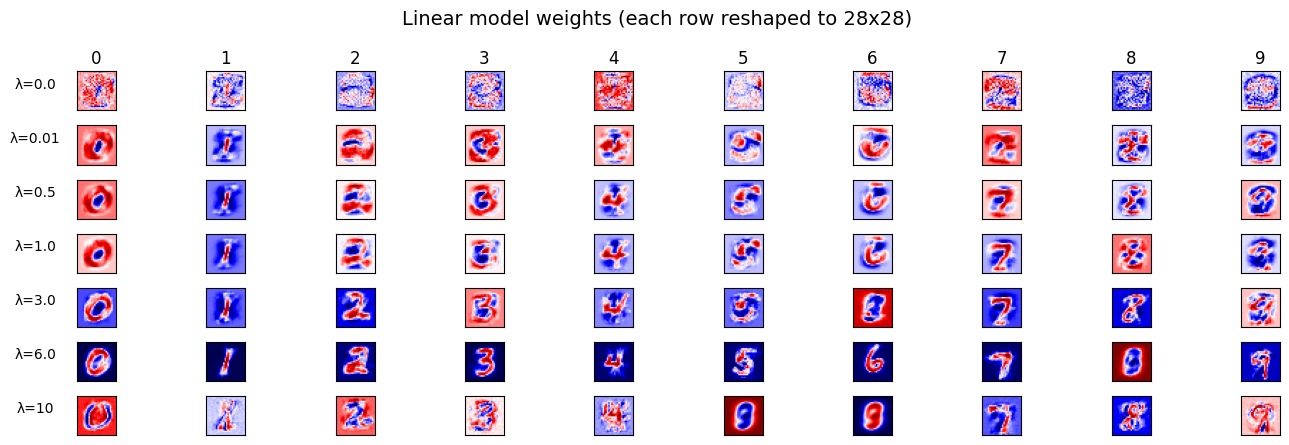

In [17]:
def plot_linear_weights(trained_models):
    # 3 lignes (lambdas), 10 colonnes (classes)
    fig, axes = plt.subplots(len(trained_models), 10, figsize=(14, 4.5))
    fig.suptitle("Linear model weights (each row reshaped to 28x28)", fontsize=14)

    for i, (lam, model) in enumerate(trained_models.items()):
        # model[0] is the Linear layer inside nn.Sequential
        W = model[0].weight.detach().cpu()   # shape: (10, 784)

        for k in range(10):
            img = W[k].view(28, 28)
            ax = axes[i, k] if len(trained_models) > 1 else axes[k]
            ax.imshow(img, cmap="seismic")  # rouge/bleu (positif/négatif)
            ax.set_xticks([])
            ax.set_yticks([])
            if i == 0:
                ax.set_title(str(k))
            if k == 0:
                ax.set_ylabel(f"λ={lam}", rotation=0, labelpad=30, fontsize=10)

    plt.tight_layout()
    plt.show()

plot_linear_weights(trained_models)


# 3) Expérience C:  Matrice de confusion (évaluation qualitative)

Après avoir entraîné notre meilleur modèle ( shallow 500), on fait :

In [18]:
#
#                                                              Metrics
# 




@torch.no_grad()
def accuracy(model, loader, device):
    model.eval()
    correct, total = 0, 0
    for X, y in loader:
        X, y = X.to(device), y.to(device)
        pred = model(X).argmax(dim=1)
        correct += (pred == y).sum().item()
        total += y.numel()
    return correct / total


@torch.no_grad()
def confusion_matrix(model, loader, device, n_classes=10):
    model.eval()
    M = torch.zeros(n_classes, n_classes, dtype=torch.long)
    for X, y in loader:
        X, y = X.to(device), y.to(device)
        pred = model(X).argmax(dim=1)
        for t, p in zip(y.view(-1), pred.view(-1)):
            M[t.long(), p.long()] += 1
    return M

In [19]:
best_model = get_mlp(layers=(500,))
best_model, _ = train_model(best_model, train_loader, test_loader, device, epochs=40, lr=0.1, lambda_l2=0.0)

cm = confusion_matrix(best_model, test_loader, device)
cm



Epoch 001 | train_loss=0.2859 | test_loss=0.1539 | test_acc=95.68%
Epoch 002 | train_loss=0.1254 | test_loss=0.1033 | test_acc=96.90%
Epoch 003 | train_loss=0.0864 | test_loss=0.0900 | test_acc=97.33%
Epoch 004 | train_loss=0.0650 | test_loss=0.0745 | test_acc=97.70%
Epoch 005 | train_loss=0.0513 | test_loss=0.0690 | test_acc=97.94%
Epoch 006 | train_loss=0.0416 | test_loss=0.0638 | test_acc=97.99%
Epoch 007 | train_loss=0.0341 | test_loss=0.0593 | test_acc=98.14%
Epoch 008 | train_loss=0.0274 | test_loss=0.0601 | test_acc=98.10%
Epoch 009 | train_loss=0.0229 | test_loss=0.0586 | test_acc=98.17%
Epoch 010 | train_loss=0.0189 | test_loss=0.0588 | test_acc=98.20%
Epoch 011 | train_loss=0.0158 | test_loss=0.0548 | test_acc=98.31%
Epoch 012 | train_loss=0.0132 | test_loss=0.0555 | test_acc=98.28%
Epoch 013 | train_loss=0.0113 | test_loss=0.0545 | test_acc=98.29%
Epoch 014 | train_loss=0.0095 | test_loss=0.0538 | test_acc=98.29%
Epoch 015 | train_loss=0.0081 | test_loss=0.0560 | test_acc=98

tensor([[ 973,    0,    1,    0,    1,    0,    2,    1,    2,    0],
        [   0, 1126,    3,    1,    0,    1,    2,    1,    1,    0],
        [   3,    2, 1014,    0,    1,    0,    2,    6,    4,    0],
        [   0,    0,    4,  992,    0,    4,    0,    2,    3,    5],
        [   2,    0,    2,    1,  964,    0,    3,    2,    0,    8],
        [   2,    0,    0,    5,    1,  877,    2,    1,    3,    1],
        [   4,    2,    0,    1,    4,    3,  942,    0,    2,    0],
        [   1,    4,    7,    2,    0,    0,    0, 1006,    4,    4],
        [   2,    0,    4,    3,    2,    3,    1,    2,  953,    4],
        [   1,    2,    0,    4,    9,    0,    1,    5,    1,  986]])

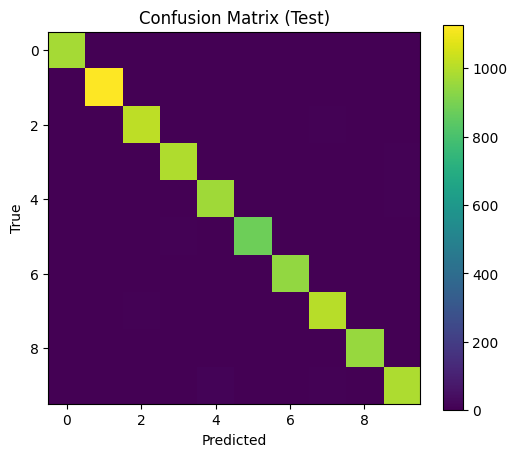

In [20]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,5))
plt.imshow(cm.cpu().numpy(), interpolation="nearest")
plt.title("Confusion Matrix (Test)")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.colorbar()
plt.show()


# 4) Expérience D: Provoquer l’overfitting (modèle énorme)

On entraîne un deep très gros et observe que test perf baisse / courbes divergent.

In [21]:
big = get_mlp(layers=(1024, 2048, 4096, 2048, 1024))
big, hist_big = train_model(big, train_loader, test_loader, device, epochs=30, lr=0.1, lambda_l2=0.0)

print("Final test acc:", accuracy(big, test_loader, device))


Epoch 001 | train_loss=0.6099 | test_loss=0.1457 | test_acc=95.61%
Epoch 002 | train_loss=0.1226 | test_loss=0.1140 | test_acc=96.39%
Epoch 003 | train_loss=0.0744 | test_loss=0.0844 | test_acc=97.35%
Epoch 004 | train_loss=0.0496 | test_loss=0.0674 | test_acc=97.83%
Epoch 005 | train_loss=0.0332 | test_loss=0.0848 | test_acc=97.50%
Epoch 006 | train_loss=0.0237 | test_loss=0.0748 | test_acc=97.92%
Epoch 007 | train_loss=0.0161 | test_loss=0.0683 | test_acc=98.37%
Epoch 008 | train_loss=0.0113 | test_loss=0.1141 | test_acc=97.26%
Epoch 009 | train_loss=0.0100 | test_loss=0.0699 | test_acc=98.21%
Epoch 010 | train_loss=0.0062 | test_loss=0.0649 | test_acc=98.34%
Epoch 011 | train_loss=0.0070 | test_loss=0.0845 | test_acc=98.06%
Epoch 012 | train_loss=0.0032 | test_loss=0.0716 | test_acc=98.48%
Epoch 013 | train_loss=0.0010 | test_loss=0.0714 | test_acc=98.48%
Epoch 014 | train_loss=0.0012 | test_loss=0.0851 | test_acc=98.31%
Epoch 015 | train_loss=0.0009 | test_loss=0.0743 | test_acc=98


Training chosen MLP with lambda = 0.0
Epoch 001 | train_loss=0.3195 | test_loss=0.1455 | train_acc=90.56% | test_acc=95.69%
Epoch 002 | train_loss=0.1193 | test_loss=0.0998 | train_acc=96.39% | test_acc=96.97%
Epoch 003 | train_loss=0.0789 | test_loss=0.0805 | train_acc=97.63% | test_acc=97.57%
Epoch 004 | train_loss=0.0571 | test_loss=0.0801 | train_acc=98.27% | test_acc=97.45%
Epoch 005 | train_loss=0.0422 | test_loss=0.0647 | train_acc=98.74% | test_acc=97.95%
Epoch 006 | train_loss=0.0311 | test_loss=0.0609 | train_acc=99.09% | test_acc=98.11%
Epoch 007 | train_loss=0.0229 | test_loss=0.0657 | train_acc=99.39% | test_acc=98.06%
Epoch 008 | train_loss=0.0170 | test_loss=0.0600 | train_acc=99.54% | test_acc=98.10%
Epoch 009 | train_loss=0.0124 | test_loss=0.0608 | train_acc=99.74% | test_acc=98.17%
Epoch 010 | train_loss=0.0086 | test_loss=0.0578 | train_acc=99.86% | test_acc=98.25%
Epoch 011 | train_loss=0.0059 | test_loss=0.0583 | train_acc=99.94% | test_acc=98.23%
Epoch 012 | tra

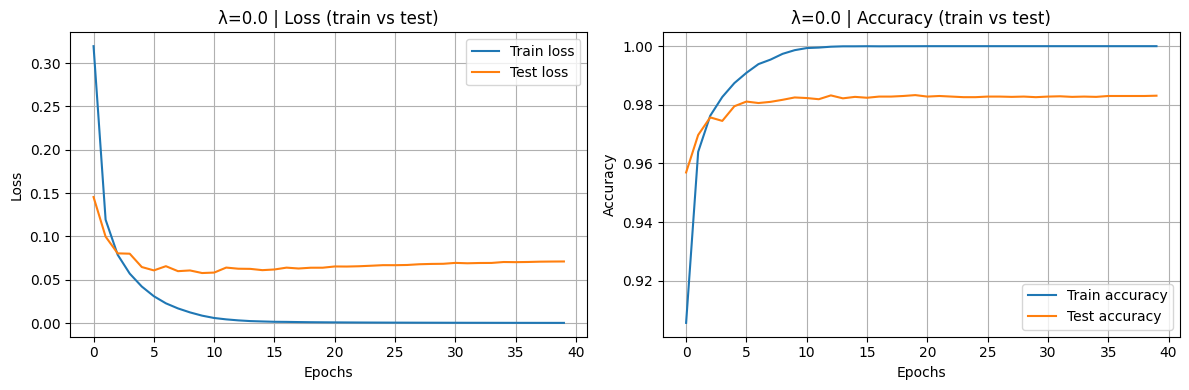


Training chosen MLP with lambda = 0.0001
Epoch 001 | train_loss=0.3559 | test_loss=0.1458 | train_acc=90.56% | test_acc=95.70%
Epoch 002 | train_loss=0.1576 | test_loss=0.1007 | train_acc=96.35% | test_acc=96.99%
Epoch 003 | train_loss=0.1183 | test_loss=0.0826 | train_acc=97.62% | test_acc=97.48%
Epoch 004 | train_loss=0.0973 | test_loss=0.0797 | train_acc=98.24% | test_acc=97.43%
Epoch 005 | train_loss=0.0831 | test_loss=0.0654 | train_acc=98.69% | test_acc=97.85%
Epoch 006 | train_loss=0.0726 | test_loss=0.0608 | train_acc=99.03% | test_acc=98.12%
Epoch 007 | train_loss=0.0647 | test_loss=0.0636 | train_acc=99.32% | test_acc=98.09%
Epoch 008 | train_loss=0.0588 | test_loss=0.0598 | train_acc=99.49% | test_acc=97.99%
Epoch 009 | train_loss=0.0543 | test_loss=0.0603 | train_acc=99.68% | test_acc=98.14%
Epoch 010 | train_loss=0.0505 | test_loss=0.0556 | train_acc=99.79% | test_acc=98.28%
Epoch 011 | train_loss=0.0475 | test_loss=0.0555 | train_acc=99.89% | test_acc=98.26%
Epoch 012 | 

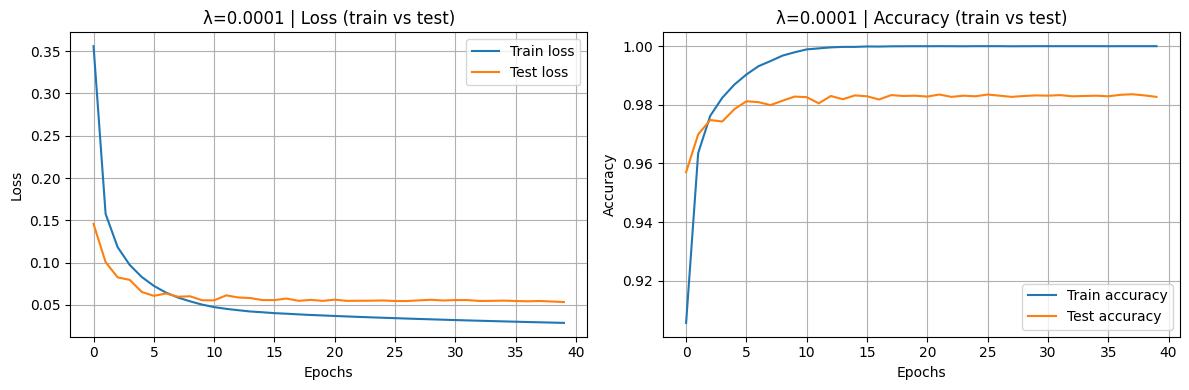


Training chosen MLP with lambda = 0.0005
Epoch 001 | train_loss=0.4944 | test_loss=0.1494 | train_acc=90.48% | test_acc=95.53%
Epoch 002 | train_loss=0.2892 | test_loss=0.1039 | train_acc=96.28% | test_acc=96.96%
Epoch 003 | train_loss=0.2410 | test_loss=0.0848 | train_acc=97.47% | test_acc=97.48%
Epoch 004 | train_loss=0.2117 | test_loss=0.0808 | train_acc=98.08% | test_acc=97.41%
Epoch 005 | train_loss=0.1893 | test_loss=0.0686 | train_acc=98.51% | test_acc=97.67%
Epoch 006 | train_loss=0.1719 | test_loss=0.0655 | train_acc=98.76% | test_acc=97.91%
Epoch 007 | train_loss=0.1577 | test_loss=0.0655 | train_acc=99.02% | test_acc=97.92%
Epoch 008 | train_loss=0.1456 | test_loss=0.0611 | train_acc=99.20% | test_acc=97.98%
Epoch 009 | train_loss=0.1359 | test_loss=0.0620 | train_acc=99.32% | test_acc=98.05%
Epoch 010 | train_loss=0.1266 | test_loss=0.0567 | train_acc=99.46% | test_acc=98.26%
Epoch 011 | train_loss=0.1193 | test_loss=0.0553 | train_acc=99.51% | test_acc=98.21%
Epoch 012 | 

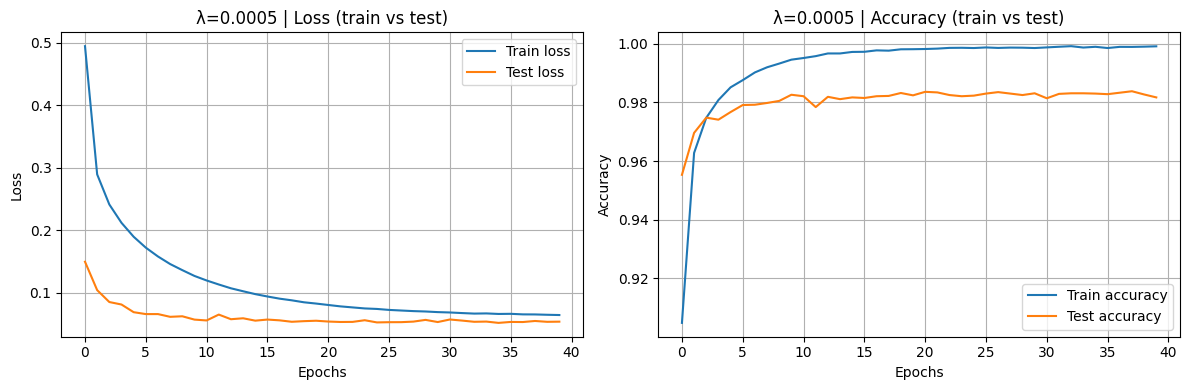


Training chosen MLP with lambda = 0.001
Epoch 001 | train_loss=0.6511 | test_loss=0.1542 | train_acc=90.42% | test_acc=95.44%
Epoch 002 | train_loss=0.4115 | test_loss=0.1092 | train_acc=96.18% | test_acc=96.83%
Epoch 003 | train_loss=0.3351 | test_loss=0.0904 | train_acc=97.30% | test_acc=97.33%
Epoch 004 | train_loss=0.2842 | test_loss=0.0847 | train_acc=97.83% | test_acc=97.46%
Epoch 005 | train_loss=0.2460 | test_loss=0.0735 | train_acc=98.25% | test_acc=97.71%
Epoch 006 | train_loss=0.2174 | test_loss=0.0720 | train_acc=98.47% | test_acc=97.68%
Epoch 007 | train_loss=0.1954 | test_loss=0.0711 | train_acc=98.71% | test_acc=97.87%
Epoch 008 | train_loss=0.1779 | test_loss=0.0691 | train_acc=98.83% | test_acc=97.77%
Epoch 009 | train_loss=0.1652 | test_loss=0.0680 | train_acc=98.91% | test_acc=97.90%
Epoch 010 | train_loss=0.1541 | test_loss=0.0625 | train_acc=98.95% | test_acc=98.03%
Epoch 011 | train_loss=0.1458 | test_loss=0.0613 | train_acc=99.04% | test_acc=98.12%
Epoch 012 | t

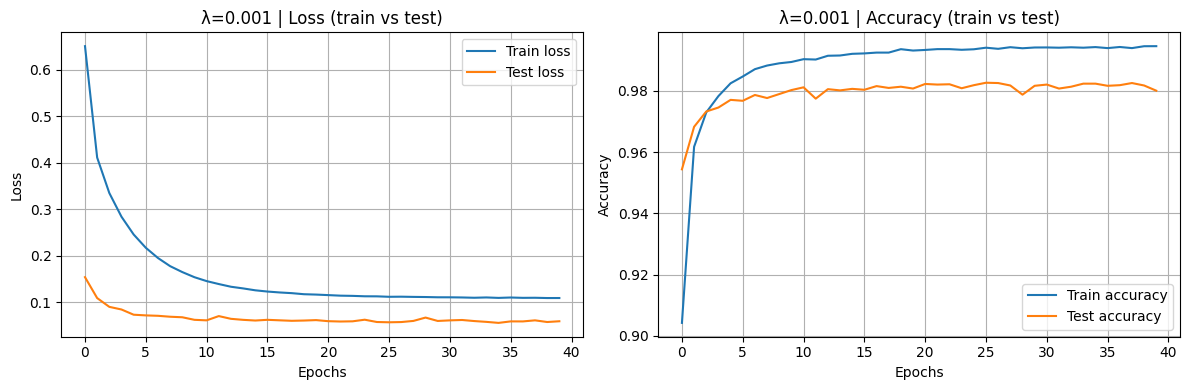


Training chosen MLP with lambda = 0.01
Epoch 001 | train_loss=1.8765 | test_loss=0.2527 | train_acc=88.97% | test_acc=92.99%
Epoch 002 | train_loss=0.6373 | test_loss=0.2086 | train_acc=93.56% | test_acc=94.60%
Epoch 003 | train_loss=0.5240 | test_loss=0.2041 | train_acc=94.19% | test_acc=94.87%
Epoch 004 | train_loss=0.5085 | test_loss=0.2004 | train_acc=94.43% | test_acc=94.88%
Epoch 005 | train_loss=0.5039 | test_loss=0.1971 | train_acc=94.58% | test_acc=94.89%
Epoch 006 | train_loss=0.5003 | test_loss=0.1939 | train_acc=94.78% | test_acc=94.81%
Epoch 007 | train_loss=0.4995 | test_loss=0.1944 | train_acc=94.78% | test_acc=94.93%
Epoch 008 | train_loss=0.4983 | test_loss=0.2094 | train_acc=94.87% | test_acc=94.35%
Epoch 009 | train_loss=0.4982 | test_loss=0.1917 | train_acc=94.92% | test_acc=94.95%
Epoch 010 | train_loss=0.4976 | test_loss=0.1873 | train_acc=94.85% | test_acc=95.31%
Epoch 011 | train_loss=0.4952 | test_loss=0.1954 | train_acc=94.89% | test_acc=95.02%
Epoch 012 | tr

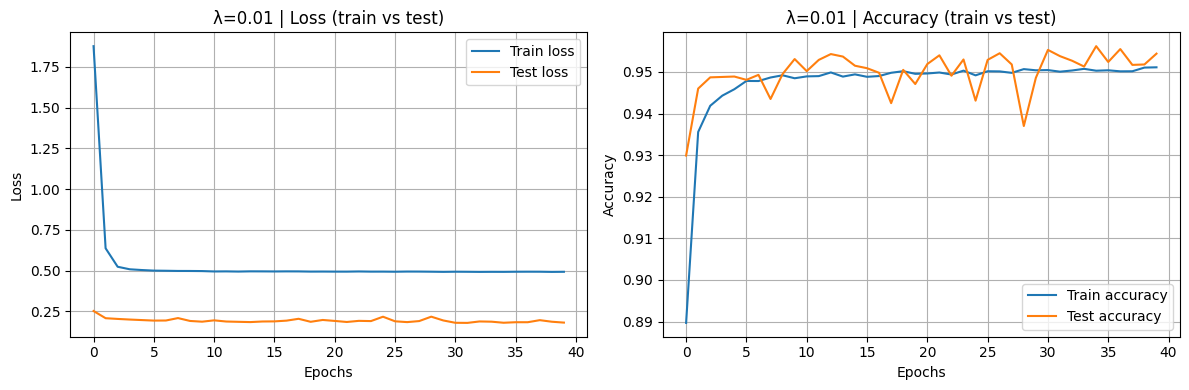


Summary (best test accuracy per lambda):
lambda=0.0     -> best_test_acc=98.33%
lambda=0.0001  -> best_test_acc=98.36%
lambda=0.0005  -> best_test_acc=98.38%
lambda=0.001   -> best_test_acc=98.27%
lambda=0.01    -> best_test_acc=95.62%


In [22]:

#                                                 A_  Definition des fonctions



# 
#                                                  Entrainement avec L2 +  historique complet
# 




def train_model(model, train_loader, test_loader, device, epochs=40, lr=0.1, lambda_l2=0.0):
    model = model.to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.SGD(model.parameters(), lr=lr)

    history = {
        "train_loss": [],
        "test_loss": [],
        "train_acc": [],
        "test_acc": []
    }

    for e in range(epochs):
        # ---- TRAIN ----
        model.train()
        running_loss = 0.0
        train_correct, train_total = 0, 0

        for X, y in train_loader:
            X, y = X.to(device), y.to(device)

            optimizer.zero_grad()
            logits = model(X)
            loss = criterion(logits, y)

            # L2 regularization 
            if lambda_l2 > 0:
                l2 = sum((p**2).sum() for p in model.parameters())
                loss = loss + lambda_l2 * l2

            loss.backward()
            optimizer.step()

            running_loss += loss.item() * X.size(0)

            pred = logits.argmax(dim=1)
            train_correct += (pred == y).sum().item()
            train_total += y.numel()

        train_loss = running_loss / len(train_loader.dataset)
        train_acc = train_correct / train_total

        # ---- TEST ----
        model.eval()
        test_running_loss = 0.0
        test_correct, test_total = 0, 0

        with torch.no_grad():
            for X, y in test_loader:
                X, y = X.to(device), y.to(device)
                logits = model(X)
                loss = criterion(logits, y)

                test_running_loss += loss.item() * X.size(0)

                pred = logits.argmax(dim=1)
                test_correct += (pred == y).sum().item()
                test_total += y.numel()

        test_loss = test_running_loss / len(test_loader.dataset)
        test_acc = test_correct / test_total

        # Store history
        history["train_loss"].append(train_loss)
        history["test_loss"].append(test_loss)
        history["train_acc"].append(train_acc)
        history["test_acc"].append(test_acc)

        print(
            f"Epoch {e+1:03d} | "
            f"train_loss={train_loss:.4f} | test_loss={test_loss:.4f} | "
            f"train_acc={100*train_acc:.2f}% | test_acc={100*test_acc:.2f}%"
        )

    return model, history


# 
#                                                               Plot 
# 







def plot_train_test_curves(history, title_prefix=""):
    plt.figure(figsize=(12,4))

    # Loss plot
    plt.subplot(1,2,1)
    plt.plot(history["train_loss"], label="Train loss")
    plt.plot(history["test_loss"], label="Test loss")
    plt.xlabel("Epochs")
    plt.ylabel("Loss")
    plt.title(f"{title_prefix} Loss (train vs test)")
    plt.legend()
    plt.grid(True)

    # Accuracy plot
    plt.subplot(1,2,2)
    plt.plot(history["train_acc"], label="Train accuracy")
    plt.plot(history["test_acc"], label="Test accuracy")
    plt.xlabel("Epochs")
    plt.ylabel("Accuracy")
    plt.title(f"{title_prefix} Accuracy (train vs test)")
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.show()


#                                                    B_ Execissions des fontions




# 
#                                                        
# 
set_seed(42)
device = get_device()
train_loader, test_loader = load_mnist(batch_size=100, normalize=True)

# Choose our MLP architecture (the one you decided to keep is get:mlp(500))
chosen_layers = (500, 500)

lambdas = [0.0, 0.0001, 0.0005, 0.001, 0.01]
all_histories = {}

for lam in lambdas:
    print(f"\n==============================")
    print(f"Training chosen MLP with lambda = {lam}")
    print(f"==============================")
    set_seed(42)

    model = get_mlp(layers=chosen_layers)
    model, history = train_model(
        model,
        train_loader,
        test_loader,
        device,
        epochs=40,
        lr=0.1,
        lambda_l2=lam
    )

    all_histories[lam] = history

    # Plot train vs test curves for this lambda
    plot_train_test_curves(history, title_prefix=f"λ={lam} |")


# summarize best test accuracy per lambda
print("\nSummary (best test accuracy per lambda):")
for lam in lambdas:
    best_acc = max(all_histories[lam]["test_acc"])
    print(f"lambda={lam:<7} -> best_test_acc={100*best_acc:.2f}%")


# 5) Expérience E: Régularisation L2 : recherche de λ

On testes plusieurs lambda_l2 et oncompare.

In [23]:
lambdas = [0.1, 0.01, 0.001, 0.0005, 0.0001, 0.00001, 0.0]
lambda_rows = []

for lam in lambdas:
    print("\n=== lambda =", lam, "===")
    set_seed(42)
    model = get_mlp(layers=(1000,1000))
    trained, hist = train_model(model, train_loader, test_loader, device, epochs=40, lr=0.1, lambda_l2=lam)
    lambda_rows.append({
        "lambda": lam,
        "best_acc": max(hist["test_acc"]),
        "final_acc": hist["test_acc"][-1],
    })

lambda_rows



=== lambda = 0.1 ===
Epoch 001 | train_loss=4.6077 | test_loss=0.8609 | train_acc=76.41% | test_acc=79.91%
Epoch 002 | train_loss=1.7529 | test_loss=0.8809 | train_acc=77.05% | test_acc=79.85%
Epoch 003 | train_loss=1.7453 | test_loss=0.8612 | train_acc=77.39% | test_acc=80.12%
Epoch 004 | train_loss=1.7463 | test_loss=0.9051 | train_acc=77.16% | test_acc=76.73%
Epoch 005 | train_loss=1.7437 | test_loss=0.8949 | train_acc=77.67% | test_acc=76.29%
Epoch 006 | train_loss=1.7449 | test_loss=0.8826 | train_acc=77.60% | test_acc=77.33%
Epoch 007 | train_loss=1.7424 | test_loss=0.8701 | train_acc=77.67% | test_acc=75.53%
Epoch 008 | train_loss=1.7416 | test_loss=0.8956 | train_acc=77.78% | test_acc=76.70%
Epoch 009 | train_loss=1.7438 | test_loss=0.8515 | train_acc=77.30% | test_acc=82.34%
Epoch 010 | train_loss=1.7410 | test_loss=0.8583 | train_acc=77.84% | test_acc=79.77%
Epoch 011 | train_loss=1.7437 | test_loss=0.8876 | train_acc=77.16% | test_acc=80.19%
Epoch 012 | train_loss=1.7426 | 

[{'lambda': 0.1, 'best_acc': 0.8234, 'final_acc': 0.7668},
 {'lambda': 0.01, 'best_acc': 0.9563, 'final_acc': 0.9488},
 {'lambda': 0.001, 'best_acc': 0.9844, 'final_acc': 0.983},
 {'lambda': 0.0005, 'best_acc': 0.9843, 'final_acc': 0.983},
 {'lambda': 0.0001, 'best_acc': 0.9843, 'final_acc': 0.9831},
 {'lambda': 1e-05, 'best_acc': 0.9842, 'final_acc': 0.9836},
 {'lambda': 0.0, 'best_acc': 0.9841, 'final_acc': 0.9841}]

* **1) Fonction : accuracy par classe sur un loader**

In [24]:
import torch

@torch.no_grad()
def per_class_accuracy(model, loader, device, n_classes=10):
    model.eval()
    correct = torch.zeros(n_classes, dtype=torch.long)
    total   = torch.zeros(n_classes, dtype=torch.long)

    for X, y in loader:
        X, y = X.to(device), y.to(device)
        logits = model(X)
        pred = logits.argmax(dim=1)

        for c in range(n_classes):
            mask = (y == c)
            total[c] += mask.sum().item()
            correct[c] += (pred[mask] == c).sum().item()

    acc = correct.float() / total.clamp_min(1).float()
    return acc.cpu()  # tensor shape (10,)


* **2) Training loop qui enregistre l’accuracy par classe (test) au fil des epochs**

Ici on garde l'idée de train_model, mais on ajoute un “tracker” par classe.


In [25]:
import torch.nn as nn

def train_with_per_class_tracking(
    model,
    train_loader,
    test_loader,
    device,
    epochs=40,
    lr=0.1,
    lambda_l2=0.0,
    track_every=5,   #  5 pour tracker toutes les 5 epochs (plus rapide)
    n_classes=10
):
    model = model.to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.SGD(model.parameters(), lr=lr)

    history = {
        "train_loss": [],
        "test_loss": [],
        "test_acc": [],
        "per_class_acc": [],   # list of tensors (10,)
        "tracked_epochs": []   # epochs where per-class is recorded
    }

    for e in range(epochs):
        # ---- TRAIN ----
        model.train()
        running_loss = 0.0

        for X, y in train_loader:
            X, y = X.to(device), y.to(device)

            optimizer.zero_grad()
            logits = model(X)
            loss = criterion(logits, y)

            if lambda_l2 > 0:
                l2 = sum((p**2).sum() for p in model.parameters())
                loss = loss + lambda_l2 * l2

            loss.backward()
            optimizer.step()

            running_loss += loss.item() * X.size(0)

        train_loss = running_loss / len(train_loader.dataset)

        # ---- TEST (loss + acc global) ----
        model.eval()
        test_running = 0.0
        correct, total = 0, 0

        with torch.no_grad():
            for X, y in test_loader:
                X, y = X.to(device), y.to(device)
                logits = model(X)
                loss = criterion(logits, y)
                test_running += loss.item() * X.size(0)

                pred = logits.argmax(dim=1)
                correct += (pred == y).sum().item()
                total += y.numel()

        test_loss = test_running / len(test_loader.dataset)
        test_acc = correct / total

        history["train_loss"].append(train_loss)
        history["test_loss"].append(test_loss)
        history["test_acc"].append(test_acc)

        # ---- PER-CLASS ACC ----
        if (e + 1) % track_every == 0:
            acc_pc = per_class_accuracy(model, test_loader, device, n_classes=n_classes)
            history["per_class_acc"].append(acc_pc)
            history["tracked_epochs"].append(e + 1)

        print(f"Epoch {e+1:03d} | train_loss={train_loss:.4f} | test_loss={test_loss:.4f} | test_acc={100*test_acc:.2f}%")

    return model, history


* **3) Exécuter l’expérience bonus**

In [26]:
import matplotlib.pyplot as plt

set_seed(42)
device = get_device()
train_loader, test_loader = load_mnist(batch_size=100, normalize=True)

model = get_mlp(layers=(500,500))  #  modèle choisi
model, hist = train_with_per_class_tracking(
    model,
    train_loader,
    test_loader,
    device,
    epochs=40,
    lr=0.1,
    lambda_l2=0.0005,   # ou 0.0, selon ce qu'on veux illustrer
    track_every=1
)


Epoch 001 | train_loss=0.4944 | test_loss=0.1494 | test_acc=95.53%
Epoch 002 | train_loss=0.2896 | test_loss=0.1095 | test_acc=96.61%
Epoch 003 | train_loss=0.2401 | test_loss=0.0881 | test_acc=97.16%
Epoch 004 | train_loss=0.2110 | test_loss=0.0729 | test_acc=97.69%
Epoch 005 | train_loss=0.1894 | test_loss=0.0724 | test_acc=97.69%
Epoch 006 | train_loss=0.1714 | test_loss=0.0664 | test_acc=97.87%
Epoch 007 | train_loss=0.1581 | test_loss=0.0656 | test_acc=97.88%
Epoch 008 | train_loss=0.1461 | test_loss=0.0620 | test_acc=97.99%
Epoch 009 | train_loss=0.1355 | test_loss=0.0643 | test_acc=97.94%
Epoch 010 | train_loss=0.1266 | test_loss=0.0587 | test_acc=98.16%
Epoch 011 | train_loss=0.1193 | test_loss=0.0573 | test_acc=98.11%
Epoch 012 | train_loss=0.1128 | test_loss=0.0570 | test_acc=98.12%
Epoch 013 | train_loss=0.1070 | test_loss=0.0576 | test_acc=98.16%
Epoch 014 | train_loss=0.1022 | test_loss=0.0602 | test_acc=98.12%
Epoch 015 | train_loss=0.0981 | test_loss=0.0547 | test_acc=98

* **4) Plot : accuracy par classe au fil des epochs**

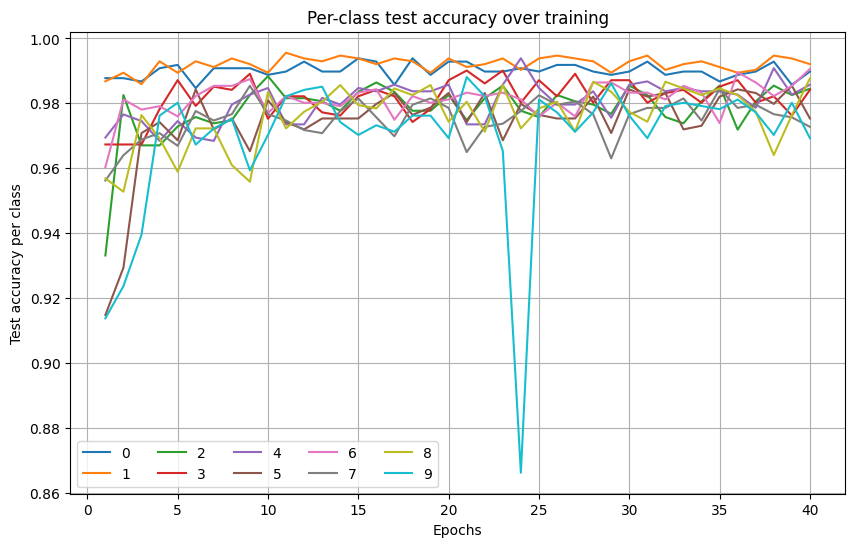

In [27]:
import torch

# hist["per_class_acc"] est une liste de tensors (10,)
pc = torch.stack(hist["per_class_acc"])   # shape: (T, 10)
epochs_tracked = hist["tracked_epochs"]

plt.figure(figsize=(10,6))
for c in range(10):
    plt.plot(epochs_tracked, pc[:, c].numpy(), label=str(c))

plt.xlabel("Epochs")
plt.ylabel("Test accuracy per class")
plt.title("Per-class test accuracy over training")
plt.legend(ncol=5)
plt.grid(True)
plt.show()



* **Heatmap per-class accuracy (au fil des epochs)**

On track toutes les 5 epochs


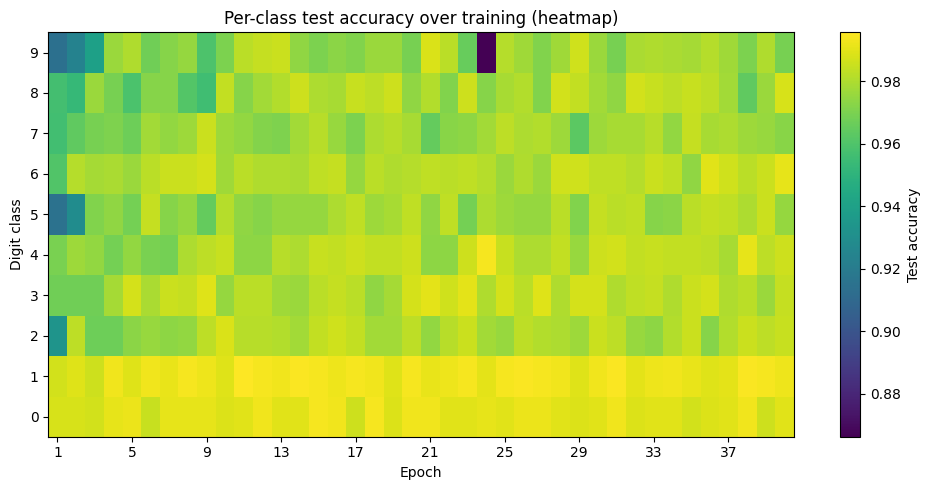

In [28]:
step = max(1, len(epochs_tracked)//10)  # ~10 labels max

plt.figure(figsize=(10, 5))
plt.imshow(pc.T, aspect="auto", origin="lower")
plt.colorbar(label="Test accuracy")

plt.yticks(range(10), [str(i) for i in range(10)])
plt.xticks(
    ticks=list(range(0, len(epochs_tracked), step)),
    labels=[epochs_tracked[i] for i in range(0, len(epochs_tracked), step)],
    rotation=0
)

plt.xlabel("Epoch")
plt.ylabel("Digit class")
plt.title("Per-class test accuracy over training (heatmap)")
plt.tight_layout()
plt.show()
